Q1. Explain GET and POST methods.
GET Method
Definition: The GET method is used to request data from a specified resource.
Characteristics:
Data in URL: The data sent by the GET method is appended to the URL as query parameters. This makes it visible in the browser's address bar.
Idempotent: GET requests can be repeated without any side effects. They do not change the state of the server.
Safe: GET requests are considered safe because they are only meant to retrieve data, not modify it.
Caching: GET requests can be cached by the browser and intermediary servers.
Length Restrictions: URLs, and therefore GET request data, can be limited in length.
Use Cases: Retrieving data, searching, accessing web pages.
Example:
from flask import Flask, request

app = Flask(__name__)

@app.route('/get_example', methods=['GET'])
def get_example():
    name = request.args.get('name')
    return f'Hello, {name}!'

if __name__ == '__main__':
    app.run(de
POST Method
Definition: The POST method is used to send data to a server to create/update a resource.
Characteristics:
Data in Body: The data sent by the POST method is included in the body of the request, not in the URL.
Not Idempotent: Multiple POST requests may result in multiple resource creations or updates.
Safe for Sending Sensitive Data: Data sent through POST is not visible in the URL, making it more suitable for sending sensitive information.
No Length Restrictions: The POST method does not have the same length restrictions as GET, allowing for larger amounts of data to be sent.
Use Cases: Submitting forms, uploading files, making transactions.

from flask import Flask, request

app = Flask(__name__)

@app.route('/post_example', methods=['POST'])
def post_example():
    name = request.form.get('name')
    return f'Hello, {name}!'

if __name__ == '__main__':
    app.run(debug=True)
bug=True)


Q2. Why is request used in Flask?
In Flask, the request object is used to handle and interact with the incoming HTTP requests from clients. It is a crucial part of building web applications because it allows developers to access and manage the data sent by clients, such as form data, query parameters, file uploads, and cookies.

Key Uses of the request Object in Flask
Accessing Form Data:

When a client submits a form, the form data can be accessed using the request.form dictionary. This is commonly used in handling POST requests.
@app.route('/submit', methods=['POST'])
def submit():
    name = request.form.get('name')
    return f'Hello, {name}
Accessing Query Parameters:

For GET requests, query parameters appended to the URL can be accessed using the request.args dictionary.@app.route('/search')
def search():
    query = request.args.get('q')
    return f'Searching for: {query
Handling JSON Data:

For APIs, JSON data sent in the body of the request can be accessed using the request.get_json() method.
@app.route('/json', methods=['POST'])
def json_example():
    data = request.get_json()
    return f"Received: {dataFile Uploads:

Files sent by clients can be accessed using the request.files dictionary. This is used to handle file upload functionality.
@app.route('/upload', methods=['POST'])
def upload_file()
:
    file = request.files['file']
    file.save(f'./uploads/{file.filename}')
    return 'File uploaded successful
Cookies:

Cookies sent by clients can be accessed using the request.cookies dictionary.
@app.route('/show_cookies')
def show_cookies():
    cookies = request.cookies
    return f'Cookies: {cookiesHTTP Headers:

HTTP headers sent by the client can be accessed using the request.headers dictionary.
@app.route('/headers')
def headers():
    user_agent = request.headers.get('User-Agent')
    return f'User-Agent: {user_agentRequest Method:

The HTTP method (GET, POST, PUT, DELETE, etc.) used by the client can be accessed using request.method.
@app.route('/method', methods=['GET', 'POST'])
def method():
    return f'Request method: {request.method}'
}'
}'
ly'
}"
}'
!'


Q3. Why is redirect() used in Flask?
In Flask, the redirect() function is used to send a user to a different endpoint (URL). This function is commonly used in scenarios where you want to dynamically change the user's location after they perform an action, such as submitting a form, logging in, or encountering an error.

Key Uses of redirect() in Flask
After Form Submission:

Redirecting the user to another page after they have submitted a form to prevent re-submission if the user refreshes the page.
from flask import Flask, redirect, url_for, request

app = Flask(__name__)

@app.route('/submit', methods=['POST'])
def submit():
    # Process the form data here
    return redirect(url_for('success'))

@app.route('/success')
def success():
    return 'Form submitted successfully!'

if __name__ == '__main__':
    app.ruUser Authentication:

Redirecting users to a login page if they try to access a restricted area without being logged in.
from flask import Flask, redirect, url_for, request, session

app = Flask(__name__)
app.secret_key = 'supersecretkey'

@app.route('/dashboard')
def dashboard():
    if 'username' in session:
        return f'Welcome {session["username"]}!'
    return redirect(url_for('login'))

@app.route('/login', methods=['GET', 'POST'])
def login():
    if request.method == 'POST':
        session['username'] = request.form['username']
        return redirect(url_for('dashboard'))
    return '''
        <form method="post">
            <p><input type=text name=username>
            <p><input type=submit value=Login>
        </form>
    '''

if __name__ == '__main__':

URL Redirection:

Redirecting users from one URL to another, for instance, redirecting from an old URL to a new URL after a site restructure.
@app.route('/old-url')
def old_url():
    return redirect(url_for('new_url'))

@app.route('/new-url')
def new_url():
    return 'This is the new 

from flask import Flask, redirect, url_for, request, session

app = Flask(__name__)
app.secret_key = 'supersecretkey'

@app.route('/')
def home():
    return 'Welcome to the home page! Go to /login to log in.'

@app.route('/login', methods=['GET', 'POST'])
def login():
    if request.method == 'POST':
        session['username'] = request.form['username']
        return redirect(url_for('dashboard'))
    return '''
        <form method="post">
            <p><input type=text name=username>
            <p><input type=submit value=Login>
        </form>
    '''

@app.route('/dashboard')
def dashboard():
    if 'username' in session:
        return f'Welcome {session["username"]}!'
    return redirect(url_for('login'))

@app.route('/logout')
def logout():
    session.pop('username', None)
    return redirect(url_for('home'))

if __name__ == '__main__':
    app.run(debug=True)
URL!'

    app.run(debug=True)
n(debug=True)


Q4. What are templates in Flask? Why is the render_template() function used?
Templates in Flask are HTML files that contain placeholders for dynamic content. They allow you to separate the presentation layer from the logic of your application, making it easier to maintain and scale your code. Templates can include placeholders for variables, control structures like loops and conditionals, and even include other templates. Flask uses the Jinja2 templating engine to render these templates.

Why Use render_template()?
The render_template() function in Flask is used to render HTML templates and return them as responses to client requests. This function takes the name of an HTML file (the template) and any number of keyword arguments that represent the data you want to pass to the template.

Benefits of Using Templates and render_template():
Separation of Concerns:

Keeps your HTML separate from your Python code, making both easier to manage.
Reusability:

Allows you to reuse HTML structures across different pages by using template inheritance.
Maintainability:

Makes it easier to update the design or layout of your web pages without touching the logic.
Dynamic Content:

Enables you to create dynamic web pages that change content based on user input or other data.


Q5. Create a simple API. Use Postman to test it. Attach the screenshot of the output in the Jupyter Notebook.from flask import Flask, jsonify, request

app = Flask(__name__)

@app.route('/api', methods=['GET'])
def get_data():
    data = {
        'message': 'Hello, World!',
        'status': 'success'
    }
    return jsonify(data)

@app.route('/api', methods=['POST'])
def post_data():
    data = request.get_json()
    response = {
        'message': 'Data received',
        'data': data
    }
    return jsonify(response), 201

if __name__ == '__main__':
  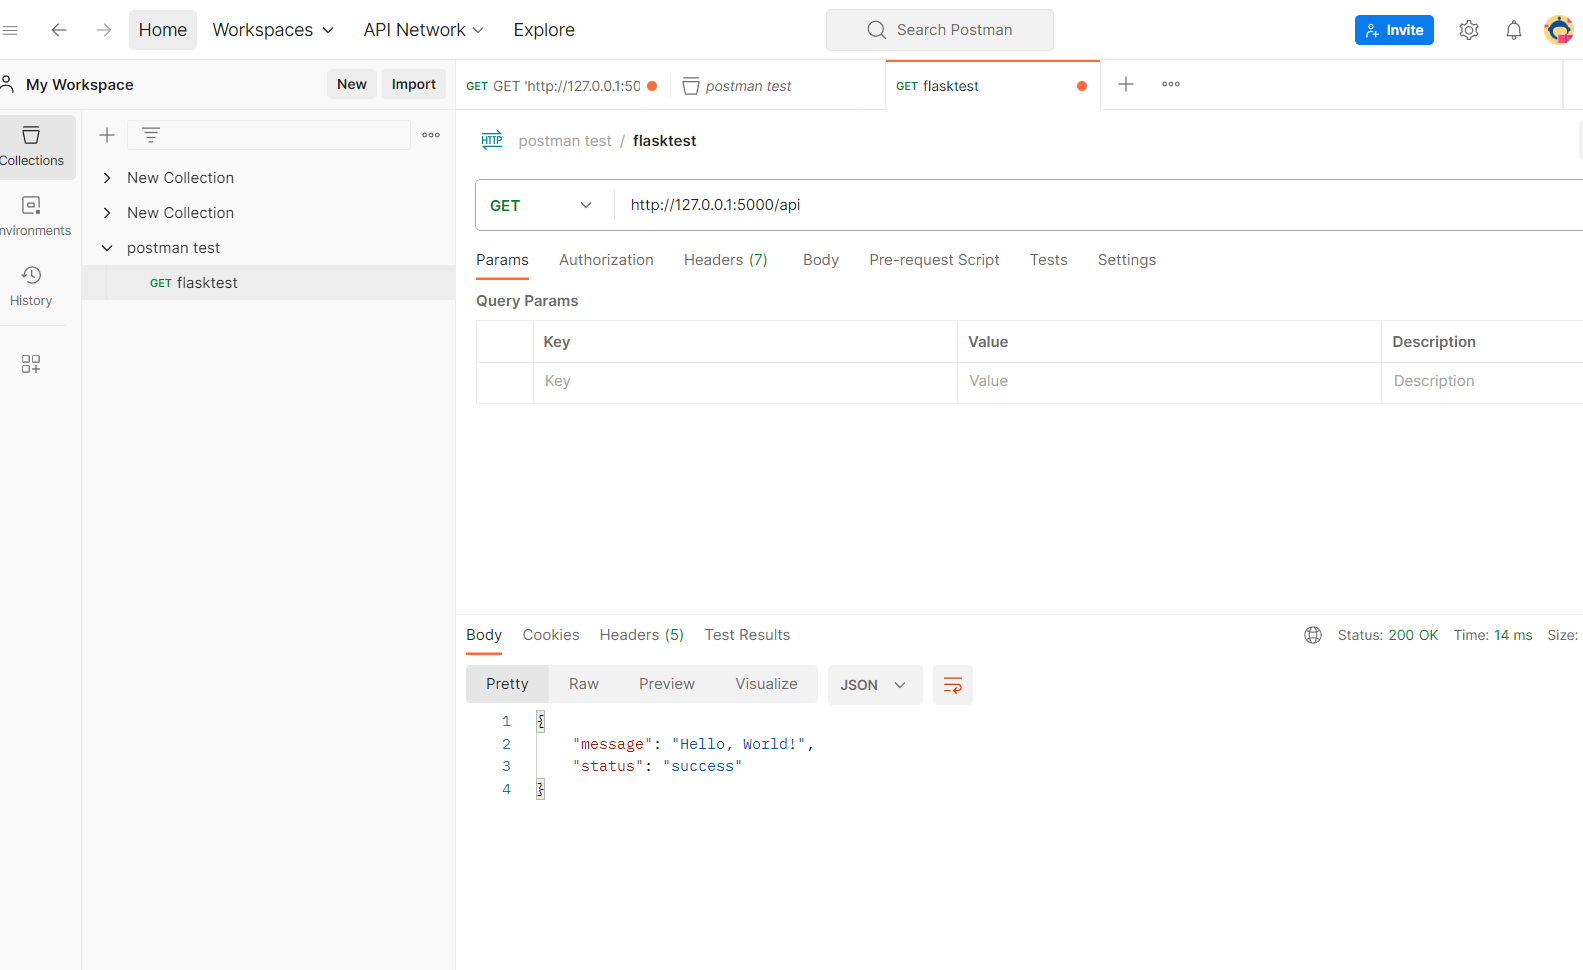  app.run(debug=True)


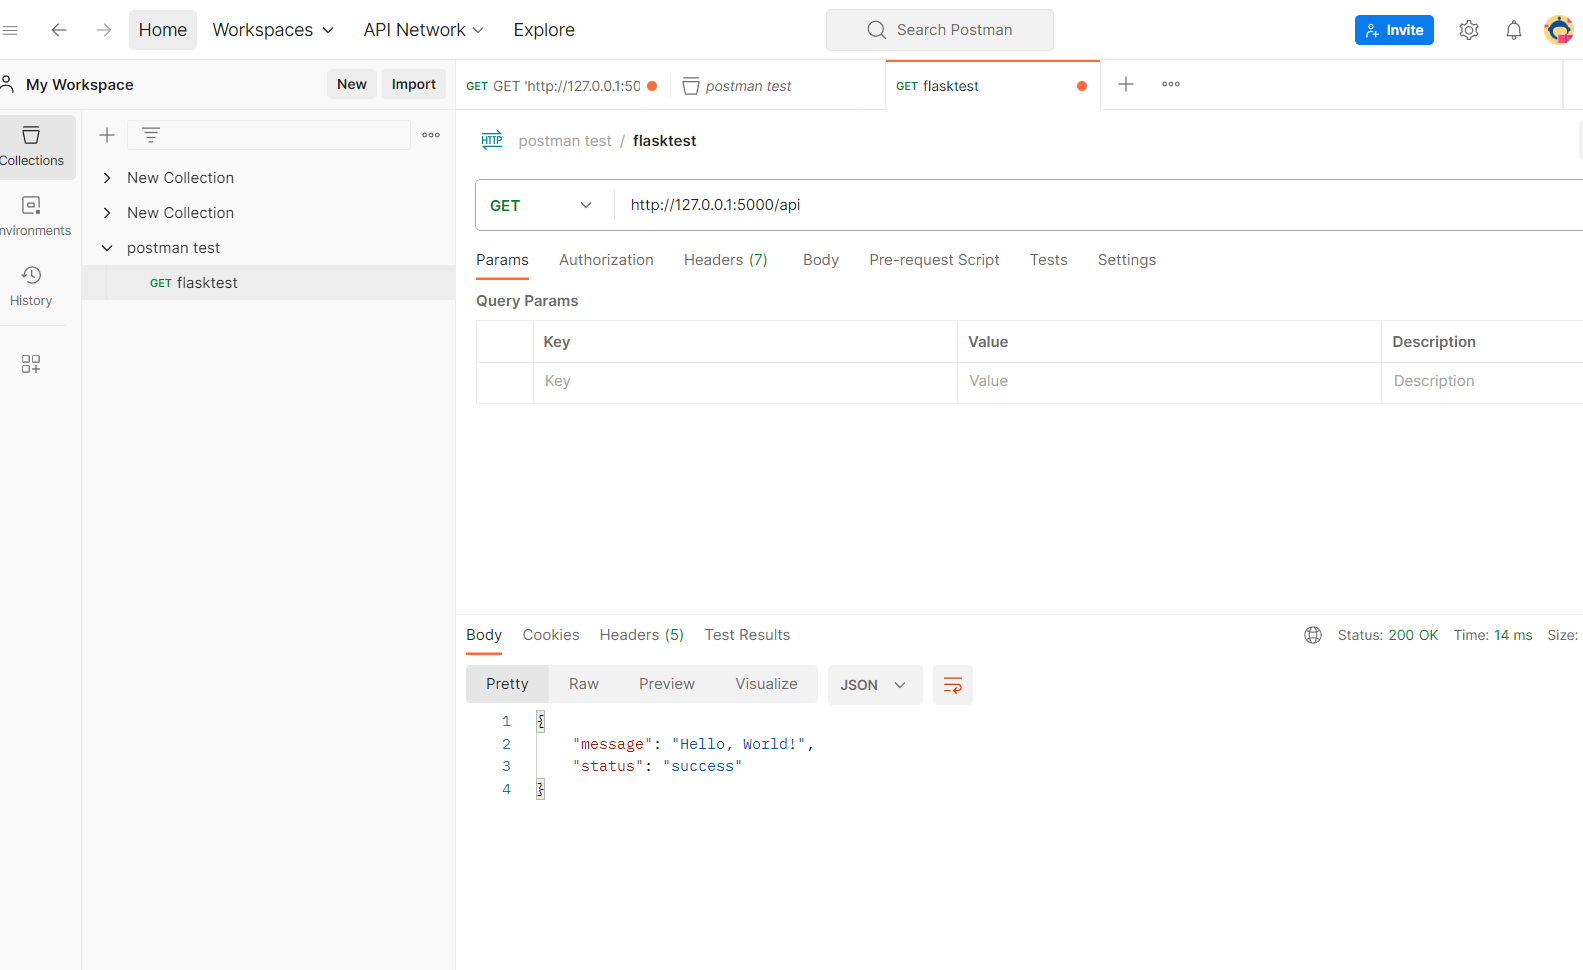